Initializing pandarallel...
INFO: Pandarallel will run on 12 workers.
INFO: Pandarallel will use standard multiprocessing data transfer (pipe) to transfer data between the main process and workers.
theta in degree: 210.74754802154717
start_angle in degree: 210.74754802154717
theta in degree: 149.25245197845285
start_angle in degree: 360.0
theta in degree: 238.03344190102192
start_angle in degree: 238.03344190102192
theta in degree: 121.96655809897804
start_angle in degree: 360.0


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


medians: [53.06877491232599, 56.35505976441435, 59.912525689520635, 60.62289013117476, 59.77715853916343, 59.53384512308511]


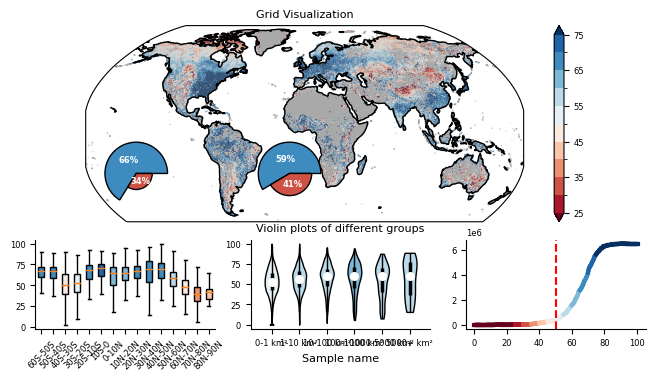

In [25]:
import sys
sys.path.append('../..')
from visualization import plot_grid
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append('../')
from correlation_analysis import correlation_plots
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

ax_mosaic = """
    aaa
    aaa
    bcd
"""

per_subplot_kw = {
    'a': {'projection': ccrs.Robinson()},
}

fig, axs = plt.subplot_mosaic(
    ax_mosaic,
    figsize=(200/25.4, 100/25.4),
    per_subplot_kw=per_subplot_kw
)

grid_pkl_path = '/data/v2/grid_all_medium.pkl'
grid_gdf = pd.read_pickle(grid_pkl_path)
grid_gdf['seasonality_dominance_percentage_median'] = grid_gdf['seasonality_dominance_percentage_median']
_, sm_of_seasonality_dominance = plot_grid(
    grid_gdf=grid_gdf.copy().to_crs(ccrs.Robinson()),
    projection=ccrs.Robinson(),
    save_path=None,
    color_column='seasonality_dominance_percentage_median',
    gridlines=False,
    add_rivers=False,
    use_log_scale_color=True,
    set_global=False,
    extent=[-180, -60, 180, 90],
    use_discrete_color=True,
    discrete_bins=[25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75],
    show=False,
    ax=axs['a'],
    draw_colorbar=True,
    return_colorbar_sm=True
)
lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)

ax_for_numbers_pie = inset_axes(axs['a'], width="100%", height="35%", loc='lower right', bbox_to_anchor=(0.4, 0.05, 0.15, 1), bbox_transform=axs['a'].transAxes, axes_class = mpl.projections.get_projection_class('polar'))
numbers_of_lakes_greater_than_50 = lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] > 50].shape[0]
numbers_of_lakes_less_than_50 = lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] <= 50].shape[0]
numbers_of_lakes_seasonality_dominance = [numbers_of_lakes_greater_than_50, numbers_of_lakes_less_than_50]
colors_for_pie = [sm_of_seasonality_dominance.to_rgba(67.5), sm_of_seasonality_dominance.to_rgba(32.5)]
correlation_plots.draw_pie_with_different_radius(
    datas=numbers_of_lakes_seasonality_dominance,
    colors=colors_for_pie,
    ax=ax_for_numbers_pie,
)

ax_for_areas_pie = inset_axes(axs['a'], width="100%", height="35%", loc='lower right', bbox_to_anchor=(0.05, 0.05, 0.15, 1), bbox_transform=axs['a'].transAxes, axes_class = mpl.projections.get_projection_class('polar'))
area_sum_of_lakes_greater_than_50 = lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] > 50]['mean_area'].sum()
area_sum_of_lakes_less_than_50 = lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] <= 50]['mean_area'].sum()
area_sum_of_lakes_seasonality_dominance = [area_sum_of_lakes_greater_than_50, area_sum_of_lakes_less_than_50]
colors_for_pie = [sm_of_seasonality_dominance.to_rgba(67.5), sm_of_seasonality_dominance.to_rgba(32.5)]
correlation_plots.draw_pie_with_different_radius(
    datas=area_sum_of_lakes_seasonality_dominance,
    colors=colors_for_pie,
    ax=ax_for_areas_pie,
)


lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)

lat_column_name = 'Pour_lat'
lat_bins = [-60, -50, -40, -30, -20, -10, 0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
lat_labels = ['60S-50S', '50S-40S', '40S-30S', '30S-20S', '20S-10S', '10S-0', '0-10N', '10N-20N', '20N-30N', '30N-40N', '40N-50N', '50N-60N', '60N-70N', '70N-80N', '80N-90N']
lat_group_colors_box = ['#7199D7', '#68A4DA', '#60AEDE', '#57B8E2', '#4EC3E5', '#45CDE9', '#4BC6E7', '#51BFE4', '#57B8E2', '#5DB1DF', '#62ABDD', '#68A4DA', '#6E9DD8', '#7496D5', '#7A8FD3']
correlation_plots.box_plot_of_different_groups(
    to_plot_df=lake_lse_gdf,
    to_plot_column_name='seasonality_dominance_percentage',
    to_group_by_column_name=lat_column_name,
    group_bins=lat_bins,
    group_labels=lat_labels,
    group_colors_box=sm_of_seasonality_dominance,
    ax=axs['b'],
    box_width=0.5,
    show_plot=False
)
axs['b'].spines['top'].set_visible(False)
axs['b'].spines['right'].set_visible(False)

lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)
lake_lse_gdf = lake_lse_gdf[(lake_lse_gdf['mean_area'] > 0)]
mean_area_column_name = 'mean_area'
mean_area_bins = [0, 1, 10, 100, 1000, 5000, np.inf]
mean_area_labels = ['0-1 km²', '1-10 km²', '10-100 km²', '100-1000 km²', '1000-5000 km²', '5000+ km²']
correlation_plots.violin_plots_of_different_groups(
    to_plot_df=lake_lse_gdf,
    to_plot_column_name='seasonality_dominance_percentage',
    to_group_by_column_name=mean_area_column_name,
    group_bins=mean_area_bins,
    group_labels=mean_area_labels,
    group_colors=sm_of_seasonality_dominance,
    show_means=False,
    show_medians=True,
    median_color='white',
    ax=axs['c'],
)
axs['c'].spines['top'].set_visible(False)
axs['c'].spines['right'].set_visible(False)

basinatlas_pkl_path = '/data/v2/basinatlas_lev06_with_statistics.pkl'
basinatlas_gdf = pd.read_pickle(basinatlas_pkl_path)
percentage_step = 0.5
percentage_ranges = np.arange(0, 101, percentage_step)
populations = []
for current_percentage in percentage_ranges:
    populations.append(basinatlas_gdf[basinatlas_gdf['seasonality_dominance_percentage_median'] < current_percentage]['pop_ct_ssu'].sum())
for i in range(len(populations)-1):
    axs['d'].plot(percentage_ranges[i:i+2], populations[i:i+2], color=sm_of_seasonality_dominance.to_rgba(percentage_ranges[i]), linewidth=3)
#axs['d'].plot(percentage_ranges, populations, color='black')
axs['d'].axvline(50, color='red', linestyle='--')
axs['d'].spines['top'].set_visible(False)
axs['d'].spines['right'].set_visible(False)

fig.savefig('/results/Fig_2_raw.pdf', bbox_inches='tight')

In [17]:
import pandas as pd
import numpy as np
lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)

In [10]:
print('Total mean area: ', lake_lse_gdf['mean_area'].sum())
print('Total mean seasonality: ', lake_lse_gdf['mean_seasonal_amplitude'].sum())
print('Total mean seasonality percentage (of total area): ', lake_lse_gdf['mean_seasonal_amplitude'].sum()/lake_lse_gdf['mean_area'].sum() * 100)
print('Total mean non-seasonal variation: ', lake_lse_gdf['annual_means_std'].sum())
print('Total mean non-seasonal variation percentage (of total area): ', lake_lse_gdf['annual_means_std'].sum()/lake_lse_gdf['mean_area'].sum() * 100)
print('Median seasonality relative contribution: ', lake_lse_gdf['seasonality_dominance_percentage'].median())

Total mean area:  2405369.263333986
Total mean seasonality:  68229.38072351851
Total mean seasonality percentage (of total area):  2.8365449647821848
Total mean non-seasonal variation:  78537.63008213993
Total mean non-seasonal variation percentage (of total area):  3.265096601977946
Median seasonality relative contribution:  53.526081586336616


In [8]:
print('Lakes ------------------------------------')
print('Total mean area: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] == 1]['mean_area'].sum())
print('Total mean area percentage: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] == 1]['mean_area'].sum()/lake_lse_gdf['mean_area'].sum() * 100)
print('Total mean seasonality: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] == 1]['mean_seasonal_amplitude'].sum())
print('Total mean seasonality percentage (of total mean seasonaltiy): ', lake_lse_gdf[lake_lse_gdf['Lake_type'] == 1]['mean_seasonal_amplitude'].sum()/lake_lse_gdf['mean_seasonal_amplitude'].sum() * 100)
print('Total mean non-seasonal variation: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] == 1]['annual_means_std'].sum())
print('Total mean non-seasonal variation percentage (of total mean non-seasonal variation): ', lake_lse_gdf[lake_lse_gdf['Lake_type'] == 1]['annual_means_std'].sum()/lake_lse_gdf['annual_means_std'].sum() * 100)

print('Reservoirs ------------------------------------')
print('Total mean area: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_area'].sum())
print('Total mean area percentage: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_area'].sum()/lake_lse_gdf['mean_area'].sum() * 100)
print('Total mean seasonality: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_seasonal_amplitude'].sum())
print('Total mean seasonality percentage (of total mean seasonaltiy): ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_seasonal_amplitude'].sum()/lake_lse_gdf['mean_seasonal_amplitude'].sum() * 100)
print('Total mean non-seasonal variation: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['annual_means_std'].sum())
print('Total mean non-seasonal variation percentage (of total mean non-seasonal variation): ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['annual_means_std'].sum()/lake_lse_gdf['annual_means_std'].sum() * 100)

Lakes ------------------------------------
Total mean area:  1941407.3856389883
Total mean area percentage:  80.7114074014599
Total mean seasonality:  56789.00416680017
Total mean seasonality percentage (of total mean seasonaltiy):  83.23247780442647
Total mean non-seasonal variation:  65848.69064980217
Total mean non-seasonal variation percentage (of total mean non-seasonal variation):  83.84349079661963
Reservoirs ------------------------------------
Total mean area:  463961.87769499735
Total mean area percentage:  19.288592598540085
Total mean seasonality:  11440.376556718302
Total mean seasonality percentage (of total mean seasonaltiy):  16.767522195573484
Total mean non-seasonal variation:  12688.939432337766
Total mean non-seasonal variation percentage (of total mean non-seasonal variation):  16.156509203380367


In [11]:
print('Reservoirs ------------------------------------')
print('Total mean area: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_area'].sum())
print('Total mean seasonality: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_seasonal_amplitude'].sum())
print('Total mean seasonality percentage (of total area): ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_seasonal_amplitude'].sum()/lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_area'].sum() * 100)
print('Total mean non-seasonal variation: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['annual_means_std'].sum())
print('Total mean non-seasonal variation percentage (of total area): ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['annual_means_std'].sum()/lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['mean_area'].sum() * 100)
print('Median seasonality dominance: ', lake_lse_gdf[lake_lse_gdf['Lake_type'] != 1]['seasonality_dominance_percentage'].median())

Reservoirs ------------------------------------
Total mean area:  463961.87769499735
Total mean seasonality:  11440.376556718302
Total mean seasonality percentage (of total area):  2.465800986398943
Total mean non-seasonal variation:  12688.939432337766
Total mean non-seasonal variation percentage (of total area):  2.7349099230690057
Median seasonality dominance:  65.36428356622676


In [21]:
print('Total mean area of seasonality-dominanted lakes: ', lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] > 50]['mean_area'].sum())
print('(Percentage) Total mean area of seasonality-dominanted lakes: ', lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] > 50]['mean_area'].sum()/lake_lse_gdf['mean_area'].sum() * 100)
print('Total numbers of seasonality-dominanted lakes: ', lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] > 50]['mean_area'].count())
print('(Percentage) Total numbers of seasonality-dominanted lakes: ', lake_lse_gdf[lake_lse_gdf['seasonality_dominance_percentage'] > 50]['mean_area'].count()/lake_lse_gdf['mean_area'].count() * 100)


Total mean area of seasonality-dominanted lakes:  1589755.5923904388
(Percentage) Total mean area of seasonality-dominanted lakes:  66.09195588484997
Total numbers of seasonality-dominanted lakes:  805065
(Percentage) Total numbers of seasonality-dominanted lakes:  57.43072131442244


In [22]:
p_value = 0.05
print('Numbers of significanly shrinking lakes :', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count())
print('Numbers of significanly shrinking lakes that are doubled by extremes:', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0) & (lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'] < -50)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count())
print('(Percentage) Numbers of significanly shrinking lakes that are doubled by extremes:', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0) & (lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'] < -50)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count() / lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count() * 100)

Numbers of significanly shrinking lakes : 262627
Numbers of significanly shrinking lakes that are doubled by extremes: 111220
(Percentage) Numbers of significanly shrinking lakes that are doubled by extremes: 42.349034943094196


In [23]:
p_value = 0.05
print('Numbers of significanly expanding lakes :', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count())
print('Numbers of significanly expanding lakes that are offset by extremes:', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0) & (lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'] < -50)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count())
print('(Percentage) Numbers of significanly expanding lakes that are offset by extremes:', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0) & (lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'] < -50)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count() / lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0)]['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'].count() * 100)


Numbers of significanly expanding lakes : 207746
Numbers of significanly expanding lakes that are offset by extremes: 94437
(Percentage) Numbers of significanly expanding lakes that are offset by extremes: 45.45791495383786


In [19]:
p_value = 0.05
print('Number of significantly expanding lakes: ', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0)]['min_deviations_of_low_water_extremes_from_annual_means_second_period'].count())
print('Total long-term change and normal seasonality of significantly expanding lakes: ', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0)]['linear_trend_of_stl_trend_per_period'].sum() * 23 + lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0)]['mean_seasonal_amplitude'].sum())
print('Total magnitudes of seasonality-induce low-water extremes of significantly expanding lakes: ', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0)]['min_deviations_of_low_water_extremes_from_annual_means_second_period'].sum())


Number of significantly expanding lakes:  207746
Total long-term change and normal seasonality of significantly expanding lakes:  48248.72227312188
Total magnitudes of seasonality-induce low-water extremes of significantly expanding lakes:  -29446.13206191216


In [20]:
p_value = 0.05
print('Number of significantly shrinking lakes: ', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0)]['min_deviations_of_low_water_extremes_from_annual_means_second_period'].count())
print('Total long-term change and normal seasonality of significantly shrinking lakes: ', np.abs(lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0)]['linear_trend_of_stl_trend_per_period'].sum()) * 23 + lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0)]['mean_seasonal_amplitude'].sum())
print('Total magnitudes of seasonality-induce low-water extremes of significantly shrinking lakes: ', lake_lse_gdf[(lake_lse_gdf['rao_mk_test_on_stl_trend_p'] < p_value) & (lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0)]['min_deviations_of_low_water_extremes_from_annual_means_second_period'].sum())


Number of significantly shrinking lakes:  262627
Total long-term change and normal seasonality of significantly shrinking lakes:  96030.1326951481
Total magnitudes of seasonality-induce low-water extremes of significantly shrinking lakes:  -54398.27539224567


In [26]:
print('Total population that do not live in a seasonality-dominated basin: ', basinatlas_gdf[basinatlas_gdf['seasonality_dominance_percentage_median'] < 50]['pop_ct_ssu'].sum())
print('(Percentage) Total population that do not live in a seasonality-dominated basin: ', basinatlas_gdf[basinatlas_gdf['seasonality_dominance_percentage_median'] < 50]['pop_ct_ssu'].sum()/basinatlas_gdf['pop_ct_ssu'].sum() * 100)
print('Total population that live in a seasonality-dominated basin: ', basinatlas_gdf[basinatlas_gdf['seasonality_dominance_percentage_median'] > 50]['pop_ct_ssu'].sum())
print('(Percentage) Total population that live in a seasonality-dominated basin: ', basinatlas_gdf[basinatlas_gdf['seasonality_dominance_percentage_median'] > 50]['pop_ct_ssu'].sum()/basinatlas_gdf['pop_ct_ssu'].sum() * 100)
print('Total population that live in a basin whose seasonality is at least twice stronger than non-seasonal variation: ', basinatlas_gdf[basinatlas_gdf['seasonality_dominance_percentage_median'] > 66.7]['pop_ct_ssu'].sum())
print('(Percentage) Total population that live in a basin whose seasonality is at least twice stronger than non-seasonal variation: ', basinatlas_gdf[basinatlas_gdf['seasonality_dominance_percentage_median'] > 66.7]['pop_ct_ssu'].sum()/basinatlas_gdf['pop_ct_ssu'].sum() * 100)


Total population that do not live in a seasonality-dominated basin:  424813.61699999997
(Percentage) Total population that do not live in a seasonality-dominated basin:  6.489547314064671
Total population that live in a seasonality-dominated basin:  6093860.354
(Percentage) Total population that live in a seasonality-dominated basin:  93.09116636104886
Total population that live in a basin whose seasonality is at least twice stronger than non-seasonal variation:  3334532.906
(Percentage) Total population that live in a basin whose seasonality is at least twice stronger than non-seasonal variation:  50.939066446621375


In [27]:
print('Total population that live in a basin with decreasing seasonaltiy: ', basinatlas_gdf[basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] < 0]['pop_ct_ssu'].sum())
print('(Percentage) Total population that live in a basin with decreasing seasonaltiy: ', basinatlas_gdf[basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] < 0]['pop_ct_ssu'].sum()/basinatlas_gdf['pop_ct_ssu'].sum())
print('Total population that live in a basin with increasing seasonaltiy: ', basinatlas_gdf[basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] > 0]['pop_ct_ssu'].sum())
print('(Percentage) Total population that live in a basin with increasing seasonaltiy: ', basinatlas_gdf[basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] > 0]['pop_ct_ssu'].sum()/basinatlas_gdf['pop_ct_ssu'].sum())
print('Total population that live in a basin with rapidly increasing (>5%) seasonaltiy: ', basinatlas_gdf[basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] > 0.5]['pop_ct_ssu'].sum())
print('(Percentage) Total population that live in a basin with rapidly increasing (>5%) seasonaltiy: ', basinatlas_gdf[basinatlas_gdf['linear_trend_of_standard_deviation_percentage_per_period_median'] > 0.5]['pop_ct_ssu'].sum()/basinatlas_gdf['pop_ct_ssu'].sum())

Total population that live in a basin with decreasing seasonaltiy:  3447118.9749999996
(Percentage) Total population that live in a basin with decreasing seasonaltiy:  0.5265895628169709
Total population that live in a basin with increasing seasonaltiy:  3071487.65
(Percentage) Total population that live in a basin with increasing seasonaltiy:  0.4692072860093915
Total population that live in a basin with rapidly increasing (>5%) seasonaltiy:  1415409.645
(Percentage) Total population that live in a basin with rapidly increasing (>5%) seasonaltiy:  0.21622112598172627


In [5]:
print('Numbers of lakes with increasing seasonality', lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] > 0]['linear_trend_of_standard_deviation_per_period'].count())
print('(Percentage) Numbers of lakes with increasing seasonality', lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] > 0]['linear_trend_of_standard_deviation_per_period'].count()/(lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] > 0]['linear_trend_of_standard_deviation_per_period'].count() + lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] < 0]['linear_trend_of_standard_deviation_per_period'].count()))
print('Total magnitudes of changes in seasonality of lakes with increasing trends: ', lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] > 0]['linear_trend_of_standard_deviation_per_period'].sum()*10)
print('Numbers of lakes with decreasing seasonality', lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] < 0]['linear_trend_of_standard_deviation_per_period'].count())
print('(Percentage) Numbers of lakes with decreasing seasonality', lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] < 0]['linear_trend_of_standard_deviation_per_period'].count()/(lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] > 0]['linear_trend_of_standard_deviation_per_period'].count() + lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] < 0]['linear_trend_of_standard_deviation_per_period'].count()))
print(lake_lse_gdf[lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] < 0]['linear_trend_of_standard_deviation_per_period'].sum()*10)

-1082.9372784063032
692963
0.5275582038919582
5824.036557714307
620566
0.47244179610804177
-6906.97383612061


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)


1287276


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

medians: [-55.791522422682505, -46.64616460490678, -48.705928363900384, -50.0075065480866, -50.62233006027483, -44.106907544675046]


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


medians: [-60.0708070657887, -51.631606236059724, -53.66038623960639, -55.35645618843774, -55.36750175237684, -52.51193293301143]
1287276


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats 

medians: [-57.93256539372742, -48.20284681198428, -50.75002379448702, -52.41081515658922, -53.728817656498016, -46.00595902781117]


/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  super().__setitem__(key, value)
/usr/local/lib/python3.8/dist-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


medians: [-58.283809043182956, -50.15517238949461, -51.6446080021465, -52.66114117066994, -52.570504283237376, -51.627540467846856]


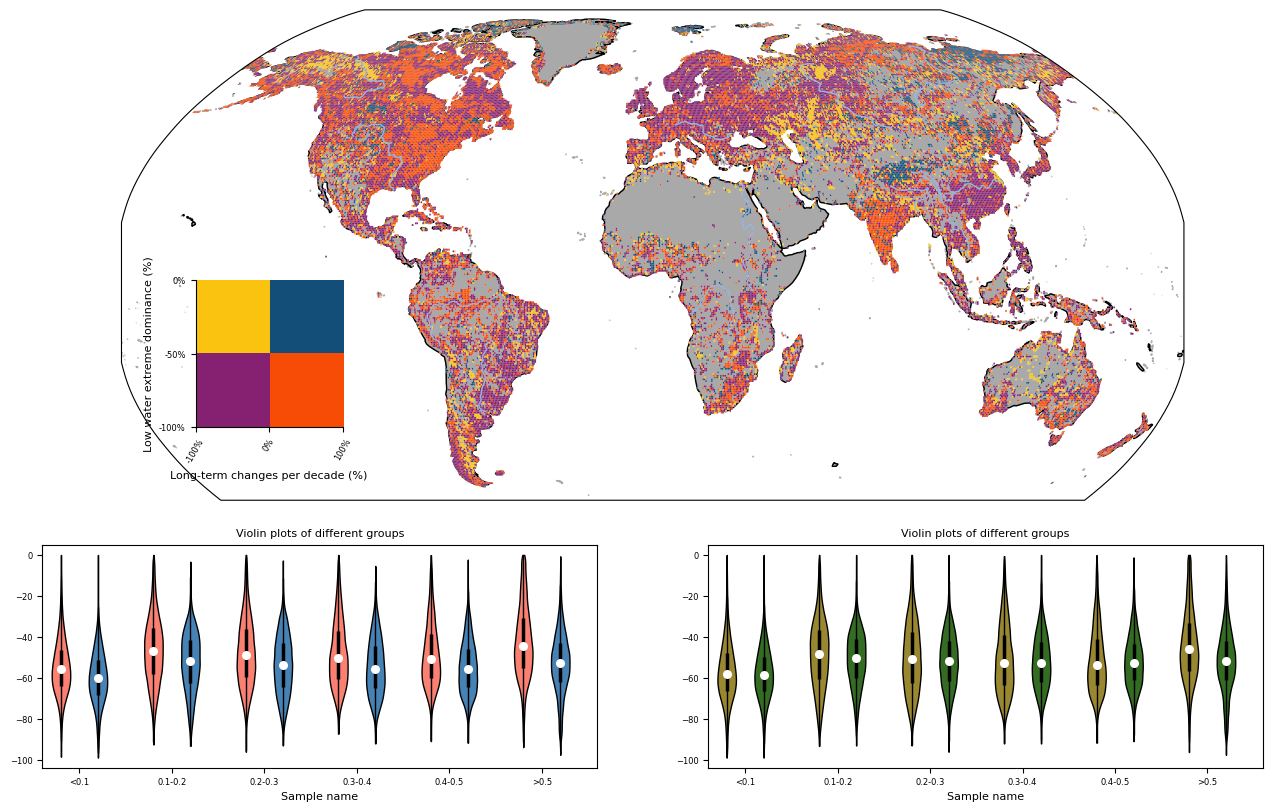

In [2]:
import sys
sys.path.append('../..')
from visualization import plot_grid
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import pandas as pd
sys.path.append('../')
from correlation_analysis import correlation_plots
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl

ax_mosaic = """
    cc
    cc
    ab
"""

per_subplot_kw = {
    'c': {'projection': ccrs.Robinson()},
}

fig, axs = plt.subplot_mosaic(
    ax_mosaic,
    figsize=(400/25.4, 250/25.4),
    per_subplot_kw=per_subplot_kw
)


upper_hex_colors_1 = ['#8E3B46', '#E8998D', '#5DB7DE', '#003249']
lower_hex_colors_1 = ['#EFD7D1', '#EFD7D1', '#B8DEE0', '#B8DEE0']
upper_hex_colors_2 = ['#8E3B46', '#E8998D', '#5DB7DE', '#003249']
lower_hex_colors_2 = ['#84241F', '#E4734E', '#B8DEE0', '#B8DEE0']

x_intervals = [-100, 0, 100]
y_intervals = [-100, -50, 0]
# x should be the percentage changes of relative seasonality changes
x_ticks = [-100, 0, 100]
x_ticklabels = ['-100%', '0%', '100%']
# y should be the percentage_of_extreme_low_water_compared_with_long_term_changes
y_ticks = [-100, -50, 0]
y_ticklabels = ['-100%', '-50%', '0%']

xtick_positions = [np.where(np.isclose(x_intervals, val, atol=1e-6))[0][0] - 0.5 for val in x_ticks]
ytick_positions = [np.where(np.isclose(y_intervals, val, atol=1e-6))[0][0] - 0.5 for val in y_ticks]
#cmap_2d = correlation_plots.create_2d_colorbar_vertical_interpolation(
   # lower_hex_colors=lower_hex_colors,
   # upper_hex_colors=upper_hex_colors,
   # num_intervals_vertical=len(y_ticks)-1
#)
cmap_2d_in_hex = [
    ['#FAC30F', '#124E78'],
    ['#852170', '#F74C06'],
]
cmap_2d = mpl.colors.ListedColormap([color for row in cmap_2d_in_hex for color in row])
grid_pkl_path = '/data/v2/grid_all_medium.pkl'
grid_gdf = pd.read_pickle(grid_pkl_path)
grid_gdf['linear_trend_of_stl_trend_percentage_per_period_median_decade'] = grid_gdf['linear_trend_of_stl_trend_percentage_per_period_median'] * 10

correlation_plots.gdf_plotting_using_2d_colobar(
    to_plot_gdf=grid_gdf,
    x_column_name='linear_trend_of_stl_trend_percentage_per_period_median_decade',
    y_column_name='percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity_median',
    x_intervals=x_ticks,
    y_intervals=y_ticks,
    cmap_2d=cmap_2d,
    ax=axs['c'],
    projection=ccrs.Robinson(),
    extent=[-180, -60, 180, 90],
    gridlines=False,
    cmap_xtick_positions=xtick_positions,
    cmap_xtick_labels=x_ticklabels,
    cmap_xlabel='Long-term changes per decade (%)',
    cmap_ytick_positions=ytick_positions,
    cmap_ytick_labels=y_ticklabels,
    cmap_ylabel='Low water extreme dominance (%)',
    show_plot=False,
    set_global=False
)
grid_gdf.plot(ax=axs['c'], facecolor='white', edgecolor='none', zorder=1.9, transform=ccrs.PlateCarree())

lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)
#lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_changes'] = lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] / (lake_lse_gdf['linear_trend_of_stl_trend_per_period'].abs()*23 + lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'].abs()) * 100
#lake_lse_gdf.to_pickle('/WORK/Data/global_lake_area/area_csvs/lakes/pkl/lakes_all_with_all_additional_attributes.pkl')
#print numbers of non na
print(lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_changes'].count())
#lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'] = lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] / (lake_lse_gdf['linear_trend_of_stl_trend_per_period'].abs()*23 + lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'].abs() + lake_lse_gdf['mean_seasonal_amplitude']) * 100
area_mk_p_column_name = 'linear_trend_of_stl_trend_percentage_per_decade_abs'
lake_lse_gdf['linear_trend_of_stl_trend_percentage_per_decade_abs'] = lake_lse_gdf['linear_trend_of_stl_trend_percentage_per_period'].abs()*10
area_mk_p_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 100]
area_mk_p_labels = ['<0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '>0.5']

correlation_plots.violin_plots_of_different_groups(
    to_plot_df=lake_lse_gdf[(lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] < 0) & (lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] < 0)],
    to_plot_column_name='percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity',
    to_group_by_column_name=area_mk_p_column_name,
    group_bins=area_mk_p_bins,
    group_labels=area_mk_p_labels,
    violin_positions=np.arange(0.5, 2.5*len(area_mk_p_labels)+0.5, 2.5),
    violin_label_positions=np.arange(1, 2.5*len(area_mk_p_labels)+1, 2.5),
    group_colors=['salmon', 'salmon', 'salmon', 'salmon', 'salmon', 'salmon'],
    show_means=False,
    ax=axs['a'],
)

correlation_plots.violin_plots_of_different_groups(
    to_plot_df=lake_lse_gdf[(lake_lse_gdf['linear_trend_of_standard_deviation_per_period'] > 0) & (lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] < 0)],
    to_plot_column_name='percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity',
    to_group_by_column_name=area_mk_p_column_name,
    group_bins=area_mk_p_bins,
    group_labels=area_mk_p_labels,
    violin_positions=np.arange(1.5, 2.5*len(area_mk_p_labels)+1.5, 2.5),
    violin_label_positions=np.arange(1, 2.5*len(area_mk_p_labels)+1, 2.5),
    group_colors=['steelblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue', 'steelblue'],
    show_means=False,
    ax=axs['a'],
)
axs['a'].set_xlim(0, 2.5*len(area_mk_p_labels))


lake_lse_pkl_path = '/data/v2/lake_lse_gdf_for_figure_making.pkl'
lake_lse_gdf = pd.read_pickle(lake_lse_pkl_path)
#lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_changes'] = lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] / (lake_lse_gdf['linear_trend_of_stl_trend_per_period'].abs()*23 + lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'].abs()) * 100
#lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'] = lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] / (lake_lse_gdf['linear_trend_of_stl_trend_per_period'].abs()*23 + lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'].abs() + lake_lse_gdf['mean_seasonal_amplitude']) * 100
#lake_lse_gdf.to_pickle('/WORK/Data/global_lake_area/area_csvs/lakes/pkl/lakes_all_with_all_additional_attributes.pkl')
#print numbers of non na
print(lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_changes'].count())
#lake_lse_gdf['percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity'] = lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] / (lake_lse_gdf['linear_trend_of_stl_trend_per_period'].abs()*23 + lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'].abs() + lake_lse_gdf['mean_seasonal_amplitude']) * 100
area_mk_p_column_name = 'linear_trend_of_stl_trend_percentage_per_decade_abs'
lake_lse_gdf['linear_trend_of_stl_trend_percentage_per_decade_abs'] = lake_lse_gdf['linear_trend_of_stl_trend_percentage_per_period'].abs()*10
area_mk_p_bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 100]
area_mk_p_labels = ['<0.1', '0.1-0.2', '0.2-0.3', '0.3-0.4', '0.4-0.5', '>0.5']

correlation_plots.violin_plots_of_different_groups(
    to_plot_df=lake_lse_gdf[(lake_lse_gdf['linear_trend_of_stl_trend_per_period'] < 0) & (lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] < 0)],
    to_plot_column_name='percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity',
    to_group_by_column_name=area_mk_p_column_name,
    group_bins=area_mk_p_bins,
    group_labels=area_mk_p_labels,
    violin_positions=np.arange(0.5, 2.5*len(area_mk_p_labels)+0.5, 2.5),
    violin_label_positions=np.arange(1, 2.5*len(area_mk_p_labels)+1, 2.5),
    group_colors=['#9A8732', '#9A8732', '#9A8732', '#9A8732', '#9A8732', '#9A8732'],
    show_means=False,
    ax=axs['b'],
)

correlation_plots.violin_plots_of_different_groups(
    to_plot_df=lake_lse_gdf[(lake_lse_gdf['linear_trend_of_stl_trend_per_period'] > 0) & (lake_lse_gdf['min_deviations_of_low_water_extremes_from_annual_means_second_period'] < 0)],
    to_plot_column_name='percentage_of_extreme_low_water_compared_with_long_term_trends_plus_average_seasonlity',
    to_group_by_column_name=area_mk_p_column_name,
    group_bins=area_mk_p_bins,
    group_labels=area_mk_p_labels,
    violin_positions=np.arange(1.5, 2.5*len(area_mk_p_labels)+1.5, 2.5),
    violin_label_positions=np.arange(1, 2.5*len(area_mk_p_labels)+1, 2.5),
    group_colors=['#346C23', '#346C23', '#346C23', '#346C23', '#346C23', '#346C23'],
    show_means=False,
    ax=axs['b'],
)
axs['b'].set_xlim(0, 2.5*len(area_mk_p_labels))

plt.savefig('/results/Fig_5_raw.pdf', format='pdf', bbox_inches='tight')